# TKAN v3 — Model Training & Evaluation

**CAC 40 Total Return | 10-day log return**

This notebook covers model architecture, walk-forward training, training diagnostics, and the interactive prediction chart.  
Feature engineering and IC analysis live in **`feature_analysis.ipynb`**.

't just fit bac---

| Section | Content |
|---------|---------|
| 1. Setup | Imports and configuration |
| 2. Data & Features | Compact data load + build feature matrix X and target y |
| 3. Architecture & Training | `build_model()`, `train_cycle()`, walk-forward (skip-if-exists) |
| 4. Training Diagnostics | Per-cycle loss curves, convergence, overfit ratio |
| 5. Inference & Predictions | Load weights, pre-compute OOS prediction cache |
| 5b. Prediction Chart | Interactive slider with empirical ±2σ confidence bands |

---
| Version | Target | Instrument | Status |
|---------|--------|------------|--------|
| v2 | LVC.PA close price (EUR) | LVC.PA | ✅ trained |
| v3 | CAC 40 TR 10d log return | C40.PA / LVC.PA | 🔨 this notebook |

## 1. Setup & Configuration

In [1]:
import os, json, pickle, warnings, pathlib, sys
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
from signum import Chart, Dashboard
import tensorflow as tf
from tkan import TKAN
from sklearn.preprocessing import RobustScaler
import plotly.io as pio
pio.renderers.default = 'notebook'

sys.path.insert(0, r"C:\Personal\Business & Investments\Python codes\sfera-db")
import sfera_db

# ── Paths ─────────────────────────────────────────────────────────────
try:
    _here = pathlib.Path(__vscode_ipynb_path__).parent
except NameError:
    _here = pathlib.Path(os.getcwd()) / 'research' / 'Index Directional' / 'tkan' / 'v3'

SCRIPT_DIR  = str(_here)
DATA_DIR    = str(_here / 'Data')
WEIGHTS_DIR = str(_here / 'weights')
OUTPUT_DIR  = str(_here / 'output')
SFERA_ENV   = str(_here.parents[6] / 'RU Market Data' / 'Python' / 'Sfera' / '.env')

for _d in (DATA_DIR, WEIGHTS_DIR, OUTPUT_DIR):
    os.makedirs(_d, exist_ok=True)

# ── Model config ──────────────────────────────────────────────────────
WINDOW_SIZE      = 30   # 30 days of context → richer temporal signal
PREDICTION_DAYS  = 5    # predict 5 signed daily log returns simultaneously
TARGET_TYPE      = 'path5d_dm'  # _dm = demeaned; changing this forces a full retrain
MAX_EPOCHS       = 25   # EarlyStopping(patience=7) will stop earlier if val_loss plateaus
BACKTEST_START   = '2015-01-01'
RETRAIN_FREQ     = 252
IVOL_EXIT_WINDOW = 126
DROPOUT_RATE     = 0.2
INITIAL_CAPITAL  = 100_000
MC_SAMPLES       = 50

INSTRUMENT_TICKER = 'C40.PA'
INSTRUMENT_LEV    = 'LVC.PA'

FEATURE_COLS = [
    'log_return_1d', 'high_low_range', 'close_to_high',
    'close_vs_sma15',
    'ivol_zscore', 'ivol_ema_ratio', 'ivol_pctl', 'ivol_roc5',
    'rvol_park20_zscore', 'vol_spread',
    'return_5d', 'return_20d',
]

print(f'Weights  → {WEIGHTS_DIR}')
print(f'Target   → {PREDICTION_DAYS}d signed daily path (demeaned)  |  Window → {WINDOW_SIZE}d context')
print(f'Epochs   → max {MAX_EPOCHS}, EarlyStopping patience=7')
print(f'Sfera    → {"✅ found" if os.path.isfile(SFERA_ENV) else "❌ not found"}')


Weights  → c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest\research\Index Directional\tkan\v3\weights
Target   → 5d signed daily path (demeaned)  |  Window → 30d context
Epochs   → max 25, EarlyStopping patience=7
Sfera    → ✅ found


## 2. Data & Features

Compact version of the data loading + feature engineering pipeline.
For in-depth feature analysis, IC charts, and vol regime dashboards see **`feature_analysis.ipynb`**.

In [2]:
# ── CACT total return close — used for log returns and the target ─────
cactr = sfera_db.query(
    "SELECT trade_date AS date, close_price AS close "
    "FROM bbgidx.index_total_return WHERE ticker = 'CACT' ORDER BY trade_date"
).assign(date=lambda d: pd.to_datetime(d['date'])).set_index('date')

# ── CAC index OHLC — real intraday high/low for range & RVol features ─
cac_ohlc = sfera_db.query(
    "SELECT trade_date AS date, open_price AS open, high_price AS high, "
    "low_price AS low, close_price AS cac_close "
    "FROM bbgidx.index_prices WHERE ticker = 'CAC' ORDER BY trade_date"
).assign(date=lambda d: pd.to_datetime(d['date'])).set_index('date')

# ── CAC IVol ──────────────────────────────────────────────────────────
ivol_raw = sfera_db.query(
    'SELECT trade_date AS date, "3m_50d_ivol" AS ivol '
    "FROM bbgidx.index_implied_vol WHERE ticker = 'CAC' ORDER BY trade_date"
).assign(date=lambda d: pd.to_datetime(d['date'])).set_index('date')[['ivol']]

# ── Align all three on common dates ───────────────────────────────────
common = cactr.index.intersection(cac_ohlc.index).intersection(ivol_raw.index)
df = cac_ohlc.loc[common].copy()            # open, high, low, cac_close — real OHLC
df['close'] = cactr.loc[common, 'close']    # CACT TR close — for returns & target
df['ivol']  = ivol_raw.loc[common, 'ivol']
print(f'Aligned: {df.index[0].date()} → {df.index[-1].date()}  ({len(df):,} rows)')

# ── Feature engineering ───────────────────────────────────────────────
df['log_return_1d']  = np.log(df['close'] / df['close'].shift(1))
df['high_low_range'] = (df['high'] - df['low']) / df['close'].shift(1).replace(0, np.nan)
df['close_to_high']  = (df['high'] - df['cac_close']) / (df['high'] - df['low'] + 1e-9)
df['sma15']          = df['close'].rolling(15).mean()
df['close_vs_sma15'] = df['close'] / df['sma15'] - 1
df['return_5d']      = np.log(df['close'] / df['close'].shift(5))
df['return_20d']     = np.log(df['close'] / df['close'].shift(20))
hl_sq      = np.log(df['high'] / df['low'].replace(0, np.nan)) ** 2
park       = np.sqrt((1 / (4 * np.log(2))) * hl_sq.rolling(20).mean() * 252)
close_rvol = df['log_return_1d'].rolling(20).std() * np.sqrt(252)
df['rvol_park20']        = park.where(park.notna() & (park > 0), close_rvol)
ivol = df['ivol']
df['ivol_ewma20']        = ivol.ewm(span=20).mean()
df['ivol_zscore']        = (ivol - ivol.rolling(IVOL_EXIT_WINDOW).mean()) / \
                            (ivol.rolling(IVOL_EXIT_WINDOW).std() + 1e-9)
df['ivol_ema_ratio']     = ivol / (df['ivol_ewma20'] + 1e-9)
df['ivol_pctl']          = ivol.rolling(IVOL_EXIT_WINDOW).apply(
                               lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
df['ivol_roc5']          = ivol.pct_change(5)
df['rvol_park20_zscore'] = (df['rvol_park20'] - df['rvol_park20'].rolling(IVOL_EXIT_WINDOW).mean()) / \
                            (df['rvol_park20'].rolling(IVOL_EXIT_WINDOW).std() + 1e-9)
df['vol_spread']         = ivol - df['rvol_park20']

# ── Target: 5 signed daily log returns (full forward path) ────────────
# y[t] = [r_{t+1}, r_{t+2}, r_{t+3}, r_{t+4}, r_{t+5}]
# where r_{t+i} = log(close[t+i] / close[t+i-1])
#
# Why this target?
#   • Signed → model sees up AND down moves; threshold on cumulative sum is meaningful
#   • Full path → TKAN sub-layers can specialise per horizon (day-1 vs day-3 vs day-5)
#   • 5× more gradient per training window vs a single scalar target
#   • Stationary: daily log returns ≈ I(0), unlike price which is I(1)
y = pd.DataFrame({
    f'r{i}': np.log(df['close'].shift(-i) / df['close'].shift(-(i - 1)))
    for i in range(1, PREDICTION_DAYS + 1)
}, index=df.index)

X     = df[FEATURE_COLS].copy()
valid = X.notna().all(axis=1) & y.notna().all(axis=1)
X, y  = X.loc[valid], y.loc[valid]

y_cum = y.sum(axis=1)   # cumulative 5d predicted return — used for signal threshold
print(f'X: {X.shape}  |  {X.index[0].date()} → {X.index[-1].date()}')
print(f'y: {y.shape}  — {PREDICTION_DAYS} signed daily log returns per row')
print(f'y_cum ∈ [{y_cum.min():.4f}, {y_cum.max():.4f}]  μ={y_cum.mean():.4f}  σ={y_cum.std():.4f}')
print(f'y_cum percentiles:  p10={y_cum.quantile(.10):.4f}  p25={y_cum.quantile(.25):.4f}  '
      f'p50={y_cum.quantile(.50):.4f}  p75={y_cum.quantile(.75):.4f}  p90={y_cum.quantile(.90):.4f}')
print(f'Days with positive 5d view: {(y_cum > 0).sum()} / {len(y_cum)}  ({(y_cum > 0).mean()*100:.1f}%)')


Aligned: 2007-01-02 → 2026-03-20  (4,912 rows)
X: (4763, 12)  |  2007-07-30 → 2026-03-13
y: (4763, 5)  — 5 signed daily log returns per row
y_cum ∈ [-0.2819, 0.1697]  μ=0.0010  σ=0.0291
y_cum percentiles:  p10=-0.0326  p25=-0.0124  p50=0.0032  p75=0.0169  p90=0.0306
Days with positive 5d view: 2684 / 4763  (56.4%)


## 3. Architecture & Training

```
InputLayer(30, 12)
→  TKAN(100, return_sequences=True)  → Dropout(0.2)
→  TKAN(100, return_sequences=True)  → Dropout(0.2)
→  TKAN(100, return_sequences=False) → Dropout(0.2)   ← collapses time axis
→  Dense(5)  →  5 demeaned signed daily log returns
```

**Loss:** MSE | **Optimizer:** Adam | **Max epochs:** 25 with `EarlyStopping(patience=7, restore_best_weights=True)`  
**Target normalisation — per-cycle demeaning:**
- Before training, subtract the training-window mean from every `y` row: `yw_dm = yw - y_mean`
- The model learns *deviations* from the unconditional historical mean, not the return level itself
- `y_mean` (shape `(5,)`) is saved per cycle as `cycle_NNN_ymean.npy`
- At inference: `prediction = raw_output + y_mean` — reconstructs actual predicted returns

This removes the "flat prediction per year" pathology where each cycle's bull-market drift was baked into the weights.

**Walk-forward schedule:**
- **Cycle 0** — trains on all available history up to `BACKTEST_START`
- **Cycles 1+** — extend training window by `RETRAIN_FREQ` bars each time

Training auto-detects config mismatch vs saved manifest and retrains if needed.  
To force a full retrain manually: delete `manifest.json`.


In [3]:

def build_model(n_features):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(WINDOW_SIZE, n_features)),
        TKAN(100, return_sequences=True,  use_bias=True),
        tf.keras.layers.Dropout(DROPOUT_RATE),
        TKAN(100, return_sequences=True,  use_bias=True),
        tf.keras.layers.Dropout(DROPOUT_RATE),
        TKAN(100, return_sequences=False, use_bias=True),   # collapses time axis
        tf.keras.layers.Dropout(DROPOUT_RATE),
        tf.keras.layers.Dense(PREDICTION_DAYS),             # 5 demeaned daily returns
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_cycle(cycle_num, X_train, y_train, epochs=MAX_EPOCHS):
    """Train one walk-forward cycle. Returns (model, scaler, y_mean, history_dict).

    Target demeaning
    ----------------
    y_mean = per-column mean of y across all training windows (shape PREDICTION_DAYS).
    Model trains on (y - y_mean); pure deviations from the unconditional mean.
    y_mean is saved to disk and added back at inference to recover actual return scale.
    """
    scaler = RobustScaler()
    X_sc   = scaler.fit_transform(X_train)
    Xw, yw = [], []
    for i in range(WINDOW_SIZE, len(X_sc)):
        Xw.append(X_sc[i - WINDOW_SIZE:i])
        yw.append(y_train.iloc[i].values)       # (PREDICTION_DAYS,)
    Xw = np.array(Xw, dtype='float32')          # (N, WINDOW_SIZE, n_features)
    yw = np.array(yw, dtype='float32')          # (N, PREDICTION_DAYS)

    # ── Demean: remove training-window unconditional mean per forward day ──
    y_mean = yw.mean(axis=0)                    # (PREDICTION_DAYS,) — saved, added back at inference
    yw_dm  = yw - y_mean                        # model trains on deviations only

    model = build_model(X_train.shape[1])
    cb = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, restore_best_weights=True, verbose=0),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', patience=4, factor=0.5, verbose=0),
    ]
    hist     = model.fit(Xw, yw_dm, epochs=epochs, batch_size=32,
                         validation_split=0.15, callbacks=cb, verbose=0)
    n_ep     = len(hist.history['loss'])
    best_val = min(hist.history['val_loss'])
    print(f'  Cycle {cycle_num:03d}: {len(Xw):,} windows | {n_ep}/{epochs} epochs | '
          f'best_val={best_val:.6f} | y_mean_cum={y_mean.sum():.5f}')
    return model, scaler, y_mean, {k: [float(v) for v in vs] for k, vs in hist.history.items()}

build_model(len(FEATURE_COLS)).summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tkan (TKAN)                     │ (None, 30, 100)        │        36,676 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tkan_1 (TKAN)                   │ (None, 30, 100)        │       161,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tkan_2 (TKAN)                   │ (None, 100)            │       161,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,981 (1.38 MB)

 Trainable params: 358,861 (1.37 MB)

 Non-trainable params: 2,120 (8.28 KB)

In [4]:
# ── Walk-forward training ─────────────────────────────────────────────────────
# Auto-invalidates saved weights whenever WINDOW_SIZE, PREDICTION_DAYS, TARGET_TYPE,
# or FEATURE_COLS change.  Uses a config fingerprint stored in manifest.json.

import hashlib

def _config_fingerprint():
    """Hash of all parameters that, if changed, require a full retrain."""
    sig = f'{WINDOW_SIZE}|{PREDICTION_DAYS}|{TARGET_TYPE}|{sorted(FEATURE_COLS)}'
    return hashlib.md5(sig.encode()).hexdigest()[:12]

def _weights_complete(manifest):
    return all(
        os.path.isfile(os.path.join(WEIGHTS_DIR, f'{k}.weights.h5')) and
        os.path.isfile(os.path.join(WEIGHTS_DIR, f'{k}_scaler_X.pkl')) and
        os.path.isfile(os.path.join(WEIGHTS_DIR, f'{k}_ymean.npy'))
        for k in manifest.get('cycles', {})
    )

dates    = X.index
bt_start = pd.Timestamp(BACKTEST_START)
bt_idx   = dates.searchsorted(bt_start)

manifest_path = os.path.join(WEIGHTS_DIR, 'manifest.json')
current_fp    = _config_fingerprint()

_m = None
if os.path.isfile(manifest_path):
    _m = json.load(open(manifest_path))
    saved_fp       = _m.get('config', {}).get('fingerprint', None)
    saved_horizon  = _m.get('config', {}).get('horizon', None)
    saved_window   = _m.get('config', {}).get('window',  None)
    saved_features = _m.get('config', {}).get('features', [])

    if saved_fp != current_fp:
        changes = []
        if saved_window  != WINDOW_SIZE:     changes.append(f'window {saved_window}→{WINDOW_SIZE}')
        if saved_horizon != PREDICTION_DAYS: changes.append(f'horizon {saved_horizon}→{PREDICTION_DAYS}')
        if sorted(saved_features) != sorted(FEATURE_COLS):
            added   = set(FEATURE_COLS) - set(saved_features)
            removed = set(saved_features) - set(FEATURE_COLS)
            if added:   changes.append(f'features added: {sorted(added)}')
            if removed: changes.append(f'features removed: {sorted(removed)}')
        if not changes:
            changes = ['config fingerprint mismatch']

        print(f'⚠️  Config changed ({"; ".join(changes)}) — clearing weights & retraining')
        for _f in pathlib.Path(WEIGHTS_DIR).glob('cycle_*'):
            _f.unlink()
        _pc = os.path.join(WEIGHTS_DIR, 'pred_cache.pkl')
        if os.path.isfile(_pc): os.remove(_pc)
        os.remove(manifest_path)
        _m = None
    elif _weights_complete(_m):
        print(f'✅ Weights up-to-date ({len(_m["cycles"])} cycles)  '
              f'[window={WINDOW_SIZE}, horizon={PREDICTION_DAYS}d, {len(FEATURE_COLS)} features]')
        print(f'   Delete {manifest_path} to force retrain')
    else:
        print('⚠️  Incomplete weights — retraining missing cycles only')
        _m = None

if _m is None:
    manifest = {
        'config': {
            'window':      WINDOW_SIZE,
            'horizon':     PREDICTION_DAYS,
            'features':    FEATURE_COLS,
            'fingerprint': current_fp,
            'version':     'v3',
        },
        'cycles': {}
    }

    cycle_ends = list(range(bt_idx, len(dates), RETRAIN_FREQ))
    if cycle_ends[-1] < len(dates) - 1:
        cycle_ends.append(len(dates) - 1)

    for cycle_num, end_idx in enumerate(cycle_ends):
        cycle_key = f'cycle_{cycle_num:03d}'
        w_path  = os.path.join(WEIGHTS_DIR, f'{cycle_key}.weights.h5')
        s_path  = os.path.join(WEIGHTS_DIR, f'{cycle_key}_scaler_X.pkl')
        h_path  = os.path.join(WEIGHTS_DIR, f'{cycle_key}_history.json')
        ym_path = os.path.join(WEIGHTS_DIR, f'{cycle_key}_ymean.npy')

        if os.path.isfile(w_path) and os.path.isfile(s_path) and os.path.isfile(ym_path):
            print(f'  Cycle {cycle_num:03d}: weights exist — skipping')
        else:
            model, scaler, y_mean, hist_data = train_cycle(
                cycle_num, X.iloc[:end_idx], y.iloc[:end_idx])
            model.save_weights(w_path)
            with open(s_path, 'wb') as f: pickle.dump(scaler, f)
            with open(h_path, 'w')  as f: json.dump(hist_data, f)
            np.save(ym_path, y_mean)        # (PREDICTION_DAYS,) — added back at inference

        manifest['cycles'][cycle_key] = {
            'cycle_num':      cycle_num,
            'train_end_idx':  int(end_idx),
            'train_end_date': str(dates[end_idx].date()),
            'n_samples':      int(end_idx),
        }

    with open(manifest_path, 'w') as f: json.dump(manifest, f, indent=2)
    print(f'\n✅ Training complete — {len(cycle_ends)} cycles  '
          f'[window={WINDOW_SIZE}, horizon={PREDICTION_DAYS}d, fp={current_fp}]')


✅ Weights up-to-date (13 cycles)  [window=30, horizon=5d, 12 features]
   Delete c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest\research\Index Directional\tkan\v3\weights\manifest.json to force retrain


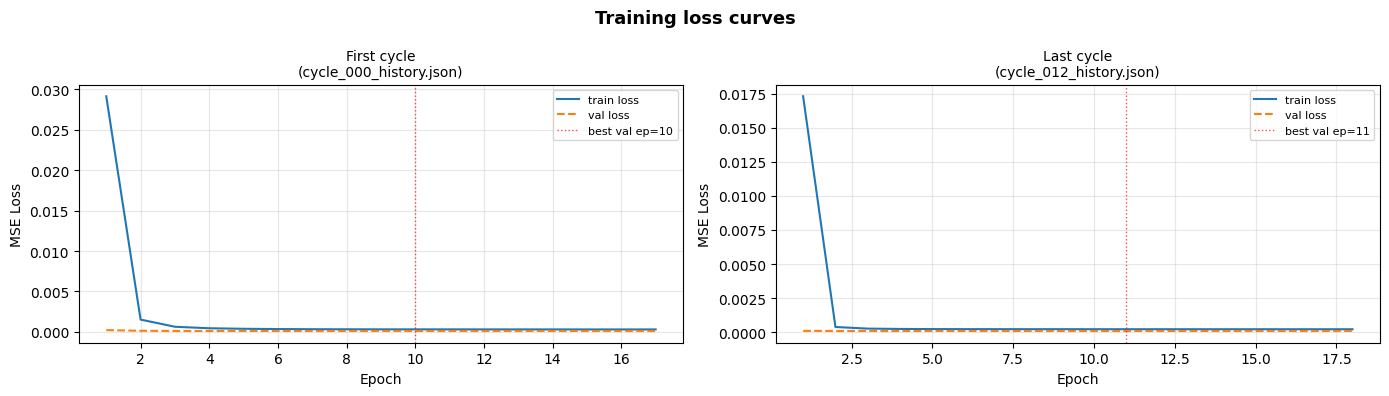

13 history files found.  Showing first + last.


In [5]:
# ── Loss curves — first & last cycle ─────────────────────────────────────────
import glob
import matplotlib.pyplot as plt

_h_files = sorted(glob.glob(os.path.join(WEIGHTS_DIR, 'cycle_*_history.json')))
if not _h_files:
    print('No history files found — run the training cell first.')
else:
    _show   = [_h_files[0], _h_files[-1]] if len(_h_files) > 1 else _h_files
    _labels = ['First cycle', 'Last cycle']  if len(_h_files) > 1 else ['Only cycle']

    fig, axes = plt.subplots(1, len(_show), figsize=(7 * len(_show), 4), squeeze=False)
    fig.suptitle('Training loss curves', fontsize=13, fontweight='bold')

    for ax, h_path, label in zip(axes[0], _show, _labels):
        with open(h_path) as _f:
            _hist = json.load(_f)
        epochs = range(1, len(_hist['loss']) + 1)
        ax.plot(epochs, _hist['loss'],     label='train loss', linewidth=1.5)
        ax.plot(epochs, _hist['val_loss'], label='val loss',   linewidth=1.5, linestyle='--')
        _best_ep = int(np.argmin(_hist['val_loss'])) + 1
        ax.axvline(_best_ep, color='red', linestyle=':', linewidth=1, alpha=0.7,
                   label=f'best val ep={_best_ep}')
        ax.set_title(f'{label}\n({os.path.basename(h_path)})', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f'{len(_h_files)} history files found.  Showing first + last.')


## 5. Inference & Predictions

In [6]:
# ── Load trained cycles ────────────────────────────────────────────────
# (run this cell independently if you skip training above)
with open(os.path.join(WEIGHTS_DIR, 'manifest.json')) as f:
    manifest = json.load(f)

cycles = sorted(manifest['cycles'].items(), key=lambda x: x[1]['cycle_num'])
n_features = len(FEATURE_COLS)
print(f'Loaded manifest: {len(cycles)} cycles')

def load_cycle(cycle_key):
    """Returns (model, scaler, y_mean); y_mean is added back to raw predictions."""
    model = build_model(n_features)
    model.load_weights(os.path.join(WEIGHTS_DIR, f'{cycle_key}.weights.h5'))
    with open(os.path.join(WEIGHTS_DIR, f'{cycle_key}_scaler_X.pkl'), 'rb') as f:
        scaler = pickle.load(f)
    ym_path = os.path.join(WEIGHTS_DIR, f'{cycle_key}_ymean.npy')
    y_mean = np.load(ym_path) if os.path.isfile(ym_path) else np.zeros(PREDICTION_DAYS, dtype='float32')
    return model, scaler, y_mean

def predict_path(model, scaler, y_mean, X_df, idx):
    """Predict next PREDICTION_DAYS signed daily log returns. Returns array of shape (PREDICTION_DAYS,)."""
    X_win = X_df.iloc[idx - WINDOW_SIZE:idx]
    X_sc  = scaler.transform(X_win).reshape(1, WINDOW_SIZE, -1)
    raw   = model(X_sc, training=False).numpy().squeeze()   # deviation from mean
    return raw + y_mean                                      # add back training-window mean

def predict_path_mc(model, scaler, y_mean, X_df, idx, n_samples=MC_SAMPLES):
    """MC Dropout: returns (mean, lo_95, hi_95) each of shape (PREDICTION_DAYS,)."""
    X_win   = X_df.iloc[idx - WINDOW_SIZE:idx]
    X_sc    = scaler.transform(X_win).reshape(1, WINDOW_SIZE, -1)
    X_batch = np.repeat(X_sc, n_samples, axis=0)
    preds   = model(X_batch, training=True).numpy() + y_mean   # (n_samples, PREDICTION_DAYS)
    m = preds.mean(axis=0)
    s = preds.std(axis=0)
    return m, m - 1.96 * s, m + 1.96 * s

# Pre-compute cycle boundaries
cycle_boundaries = [(info['train_end_idx'], key) for key, info in cycles]
model_cache = {}
dates        = X.index
bt_start_idx = dates.searchsorted(bt_start)
print(f'Backtest start idx: {bt_start_idx} ({dates[bt_start_idx].date()})')


Loaded manifest: 13 cycles
Backtest start idx: 1897 (2015-01-02)


## 5b. Signal Chart

Full backtest time series. Green shading = model predicted ≥ `ENTRY_THRESHOLD` (long entry signal). Orange bands = model retrain dates. Bottom pane shows raw predicted log-return magnitude.


In [7]:
# ── Pre-compute OOS predictions ───────────────────────────────────────────────
# Each row of pred_df = [r1, r2, r3, r4, r5] — predicted signed daily log returns.
# Signal is derived from pred_df.sum(axis=1) — the predicted 5d cumulative return.
# Cache stores the config fingerprint; auto-invalidates on config change.
PRED_CACHE  = os.path.join(WEIGHTS_DIR, 'pred_cache.pkl')
FORCE_REGEN = False   # set True to force rebuild

_loaded = False
if not FORCE_REGEN and os.path.isfile(PRED_CACHE):
    with open(PRED_CACHE, 'rb') as f:
        _cache = pickle.load(f)
    if (isinstance(_cache, tuple) and len(_cache) == 3
            and isinstance(_cache[0], pd.DataFrame)
            and isinstance(_cache[0].index, pd.DatetimeIndex)):
        pred_df, retrain_dates, _cached_fp = _cache
        if _cached_fp != current_fp:
            print(f'⚠️  Pred cache config mismatch (cached={_cached_fp}, current={current_fp}) — rebuilding')
        else:
            _expected_start = pd.Timestamp(BACKTEST_START) + pd.Timedelta(days=60)
            if pred_df.index[0] <= _expected_start:
                print(f'✅ Loaded cache: {len(pred_df)} predictions  [fp={_cached_fp}]')
                print(f'   Range: {pred_df.index[0].date()} → {pred_df.index[-1].date()}')
                _loaded = True
            else:
                print(f'⚠️  Cache starts at {pred_df.index[0].date()} — stale, rebuilding')
    else:
        print('⚠️  Old/incompatible cache format — rebuilding')

if not _loaded:
    if os.path.isfile(PRED_CACHE):
        os.remove(PRED_CACHE)

    from collections import defaultdict

    retrain_dates = []
    _preds_dict   = {}

    # Pass 1: assign each backtest idx to its cycle
    cycle_for_idx = {}
    cycle_i = 0
    cur_key = None
    for i in range(bt_start_idx, len(dates)):
        if cycle_i < len(cycle_boundaries) and i >= cycle_boundaries[cycle_i][0]:
            new_key = cycle_boundaries[cycle_i][1]
            if new_key != cur_key:
                retrain_dates.append(dates[i])
                cur_key = new_key
            cycle_i += 1
        if cur_key is None or i < WINDOW_SIZE:
            continue
        cycle_for_idx[i] = cur_key

    # Pass 2: batch predict per cycle
    cycle_groups = defaultdict(list)
    for idx, ck in cycle_for_idx.items():
        cycle_groups[ck].append(idx)

    for ck, idxs in sorted(cycle_groups.items()):
        mdl, scl, ym = load_cycle(ck)
        X_sc  = scl.transform(X).astype('float32')
        Xw    = np.stack([X_sc[i - WINDOW_SIZE:i] for i in idxs])
        preds = mdl(Xw, training=False).numpy() + ym    # add training-window mean back
        for idx, p in zip(idxs, preds):
            _preds_dict[dates[idx]] = p
        print(f'  {ck}: {len(idxs):,} preds  {dates[idxs[0]].date()} → {dates[idxs[-1]].date()}  '
              f'ym_cum={ym.sum():.5f}  ✓')

    _cols  = [f'r{i+1}' for i in range(PREDICTION_DAYS)]
    pred_df = pd.DataFrame.from_dict(_preds_dict, orient='index', columns=_cols)
    pred_df.index = pd.DatetimeIndex(pred_df.index)
    pred_df = pred_df.sort_index()

    with open(PRED_CACHE, 'wb') as f:
        pickle.dump((pred_df, retrain_dates, current_fp), f)
    print(f'✅ {len(pred_df)} predictions cached  [fp={current_fp}]')
    print(f'   Range: {pred_df.index[0].date()} → {pred_df.index[-1].date()}')

# Cumulative 5d view — quick sanity check
_cum = pred_df.sum(axis=1)
print(f'\nPred 5d-cum:  μ={_cum.mean():.4f}  σ={_cum.std():.4f}  '
      f'p25={_cum.quantile(.25):.4f}  p50={_cum.quantile(.50):.4f}  p75={_cum.quantile(.75):.4f}')
print(f'Retrains: {len(retrain_dates)}  |  {[str(d.date()) for d in retrain_dates]}')


✅ Loaded cache: 2866 predictions  [fp=306cecb666ac]
   Range: 2015-01-02 → 2026-03-13

Pred 5d-cum:  μ=0.0008  σ=0.0013  p25=0.0001  p50=0.0005  p75=0.0014
Retrains: 13  |  ['2015-01-02', '2015-12-28', '2016-12-20', '2017-12-13', '2018-12-10', '2019-12-05', '2020-12-01', '2021-11-24', '2022-11-15', '2023-11-08', '2024-11-04', '2025-10-30', '2026-03-13']


In [ ]:

# ── Signal chart + Strategy vs B&H — interactive threshold slider ─────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

ENTRY_THRESHOLD = 0.0   # 0 = long when model expects net-positive 5d return

def ts(series, col='value'):
    return pd.DataFrame({'time': series.index.strftime('%Y-%m-%d'), col: series.values})

price_bt   = df['close'].loc[df.index >= pd.Timestamp(BACKTEST_START)]
_pred_bt   = pred_df.reindex(price_bt.index)
pred_cum   = _pred_bt.sum(axis=1).fillna(0)   # predicted 5d cumulative return
_daily_ret = np.log(price_bt / price_bt.shift(1)).fillna(0)

# static retrain bands
retrain_pos = pd.Series(0, index=price_bt.index)
for _rd in retrain_dates:
    _m = (price_bt.index >= _rd) & (price_bt.index < _rd + pd.offsets.BDay(3))
    retrain_pos[_m] = 1
retrain_shade = pd.DataFrame({'time': price_bt.index.strftime('%Y-%m-%d'), 'position': retrain_pos.values})

_thr_min = float(np.percentile(pred_cum.dropna(), 5))
_thr_max = float(np.percentile(pred_cum.dropna(), 95))

def _render(thr):
    sig    = (pred_cum >= thr).astype(int)
    pos    = sig.shift(1).fillna(0)
    sr     = _daily_ret * pos
    bh_cum = _daily_ret.cumsum().apply(np.exp)
    st_cum = sr.cumsum().apply(np.exp)
    sh_bh  = (_daily_ret.mean() / (_daily_ret.std() + 1e-9)) * 252**0.5
    sh_st  = (sr.mean()         / (sr.std()         + 1e-9)) * 252**0.5
    mdd_st = float((st_cum / st_cum.cummax() - 1).min() * 100)
    mdd_bh = float((bh_cum / bh_cum.cummax() - 1).min() * 100)
    pct    = sig.mean() * 100
    print(f'Strategy: {st_cum.iloc[-1]:.2f}x  Sharpe={sh_st:.2f}  MDD={mdd_st:.1f}%  in-market={pct:.1f}%'
          f'  |  B&H: {bh_cum.iloc[-1]:.2f}x  Sharpe={sh_bh:.2f}  MDD={mdd_bh:.1f}%')
    shade_long = pd.DataFrame({'time': price_bt.index.strftime('%Y-%m-%d'), 'position': sig.values})
    p1 = Chart(height=360, watermark='CAC40 TR')
    p1.line(ts(price_bt), name='CAC40 TR', color='#4169E1')
    p1.shade(shade_long,    color='#00CC96', opacity=0.15)
    p1.shade(retrain_shade, color='#FF9500', opacity=0.40)
    p2 = Chart(height=140, watermark='Predicted 5d cumulative return')
    p2.baseline(ts(pred_cum), base_value=0)
    p2.price_line(thr, title=f'thr={thr:.4f}', color='#00CC96')
    p3 = Chart(height=180, watermark='Strategy vs B&H')
    p3.line(ts(bh_cum), name='B&H',      color='#4169E1')
    p3.line(ts(st_cum), name='Strategy', color='#00CC96')
    Dashboard(
        panes=[p1, p2, p3],
        titles=['CAC40 TR — TKAN v3', 'Predicted 5d cumulative log-return', 'Strategy vs B&H'],
    ).show()

out    = widgets.Output()
slider = widgets.FloatSlider(
    value=ENTRY_THRESHOLD, min=round(_thr_min, 4), max=round(_thr_max, 4), step=0.0005,
    description='Threshold:', readout_format='.4f',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px'),
)

def _out_render(thr):
    with out:
        clear_output(wait=True)
        _render(thr)

slider.observe(lambda c: _out_render(c['new']), names='value')
_out_render(slider.value)
display(widgets.VBox([slider, out]))
